<a href="https://colab.research.google.com/github/mmbc560/GUIA2/blob/main/8_Machine_Learning_%7C_Aprendizaje_autom%C3%A1tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



BASE DE DATOS PARA MACHINE LEARNING
     Fecha  Demanda_real  Pronostico  Error_pronostico       APE  Lead_time_dias  Riesgo_proveedor  Inventario_inicial  Compras_recibidas  Disponible  Stockout  Riesgo_stockout
2024-01-07           265         325               -60 22.641509              86                 1                 392                234         626         0                0
2024-01-14           250         262               -12  4.800000              86                 1                 232                225         457         0                0
2024-01-21           278         231                47 16.906475              92                 1                 403                144         547         0                0
2024-01-28           309         327               -18  5.825243              75                 1                 449                189         638         0                0
2024-02-04           261         222                39 14.942529             

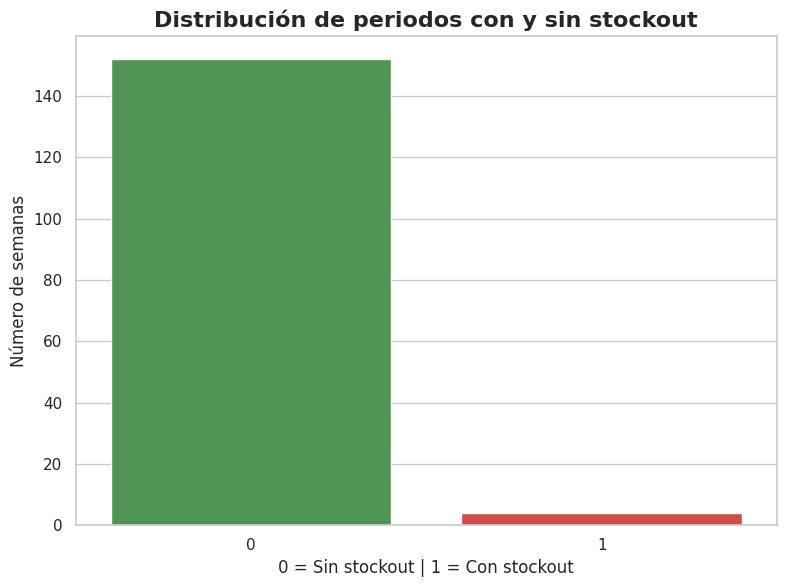


INTERPRETACIÓN

De las 156 semanas analizadas,
aproximadamente 2.6% presentan stockout.

Antes de entrenar cualquier modelo debemos observar
si las dos categorías están razonablemente representadas.

Esto es importante porque un modelo puede parecer
muy preciso simplemente por predecir siempre
la categoría mayoritaria.



DIVISIÓN DE LOS DATOS
Datos de entrenamiento: 116
Datos de prueba: 39


RESULTADOS DEL MODELO RANDOM FOREST

Accuracy:  97.44%
Precision: 0.00%
Recall:    0.00%
F1-score:  0.00%
AUC:       0.632

INTERPRETACIÓN DE LAS MÉTRICAS

ACCURACY = 97.4%

Representa el porcentaje total de predicciones correctas.


PRECISION = 0.0%

De las semanas que el modelo clasificó como
"alto riesgo de stockout",
aproximadamente este porcentaje realmente presentó stockout.


RECALL = 0.0%

De todos los stockouts que realmente ocurrieron,
el modelo logró identificar aproximadamente este porcentaje.


F1-SCORE = 0.0%

Resume el equilibrio entre Precision y Recall.


AUC = 0.632

Resume la c

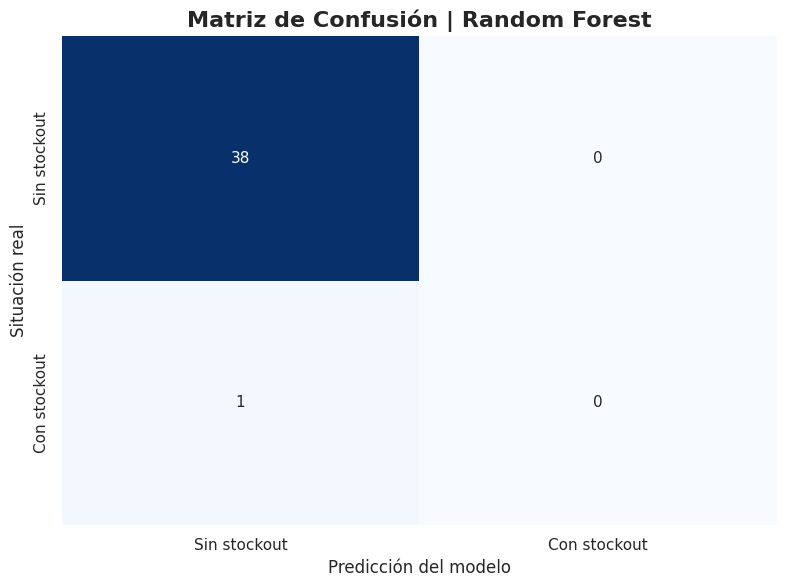


INTERPRETACIÓN DE LA MATRIZ

VERDADEROS NEGATIVOS = 38

El modelo dijo "sin riesgo"
y efectivamente no ocurrió stockout.


FALSOS POSITIVOS = 0

El modelo generó una alerta,
pero finalmente no ocurrió stockout.


FALSOS NEGATIVOS = 1

El modelo NO generó alerta,
pero sí ocurrió stockout.

Para GlobalBike este error puede ser especialmente crítico.


VERDADEROS POSITIVOS = 0

El modelo generó alerta
y efectivamente ocurrió stockout.



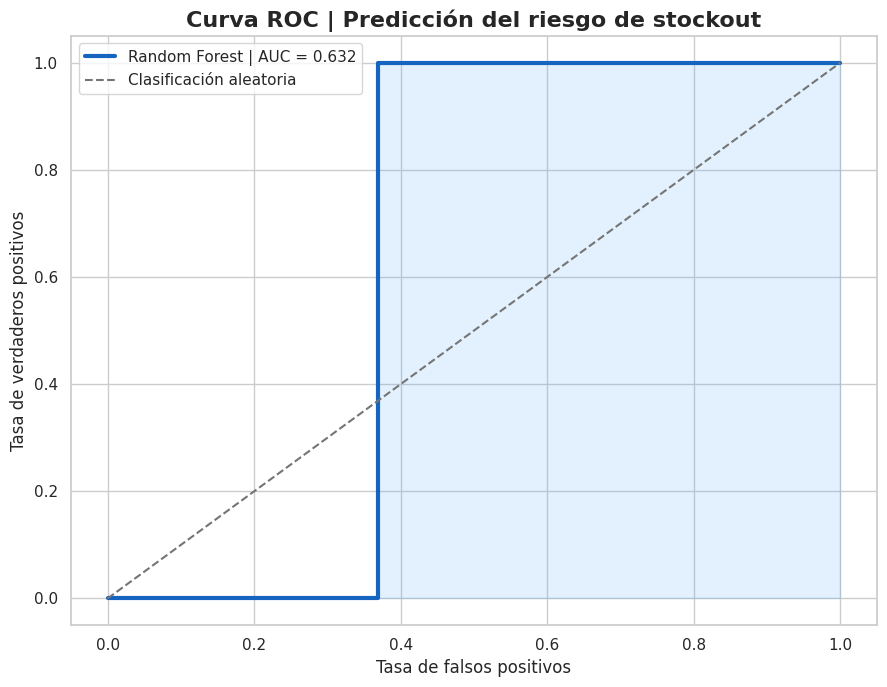


INTERPRETACIÓN CURVA ROC

El AUC obtenido es 0.632.

La curva ROC permite analizar la capacidad
del modelo para separar semanas con riesgo
y semanas sin riesgo.

Cuanto mayor sea la separación respecto
a la diagonal, mayor es la capacidad discriminatoria
del modelo dentro de esta muestra.

Sin embargo, el objetivo empresarial
no es conseguir una gráfica bonita.

El objetivo es utilizar la predicción
para tomar una decisión antes del stockout.



IMPORTANCIA DE VARIABLES
             Variable  Importancia
   Inventario_inicial     0.485152
Error_semana_anterior     0.159025
       Lead_time_dias     0.129848
           Pronostico     0.106047
  APE_semana_anterior     0.094400
     Riesgo_proveedor     0.025528


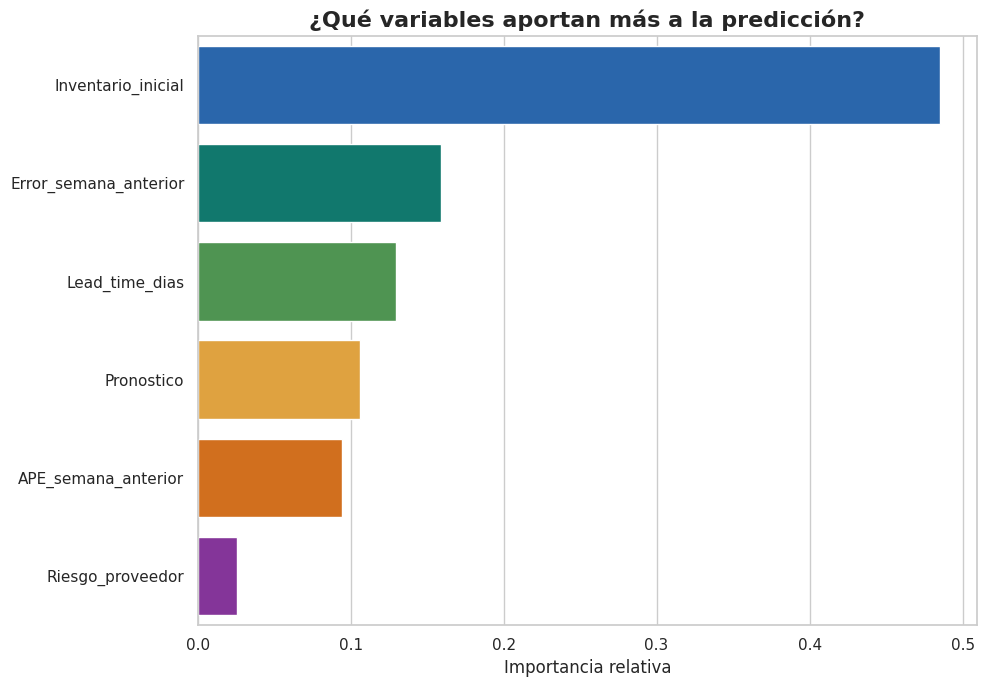


INTERPRETACIÓN

La variable con mayor importancia predictiva
en este ejercicio fue:

Inventario_inicial

con una importancia aproximada de:

48.5%

Esto NO significa necesariamente
que esta variable cause el stockout.

Significa que fue especialmente útil
para que Random Forest diferenciara
entre situaciones con y sin riesgo.

Esta información puede orientar
la investigación gerencial posterior.



EJEMPLOS DE PREDICCIONES
     Pronostico  Error_semana_anterior  APE_semana_anterior  Lead_time_dias  Riesgo_proveedor  Inventario_inicial  Situacion_real  Prediccion_modelo  Probabilidad_stockout
120         267                   -2.0                 0.58              84                 1                 158               0                  0                  12.75
111         297                   55.0                17.68              83                 2                 268               0                  0                  11.07
106         261                  118.0                33

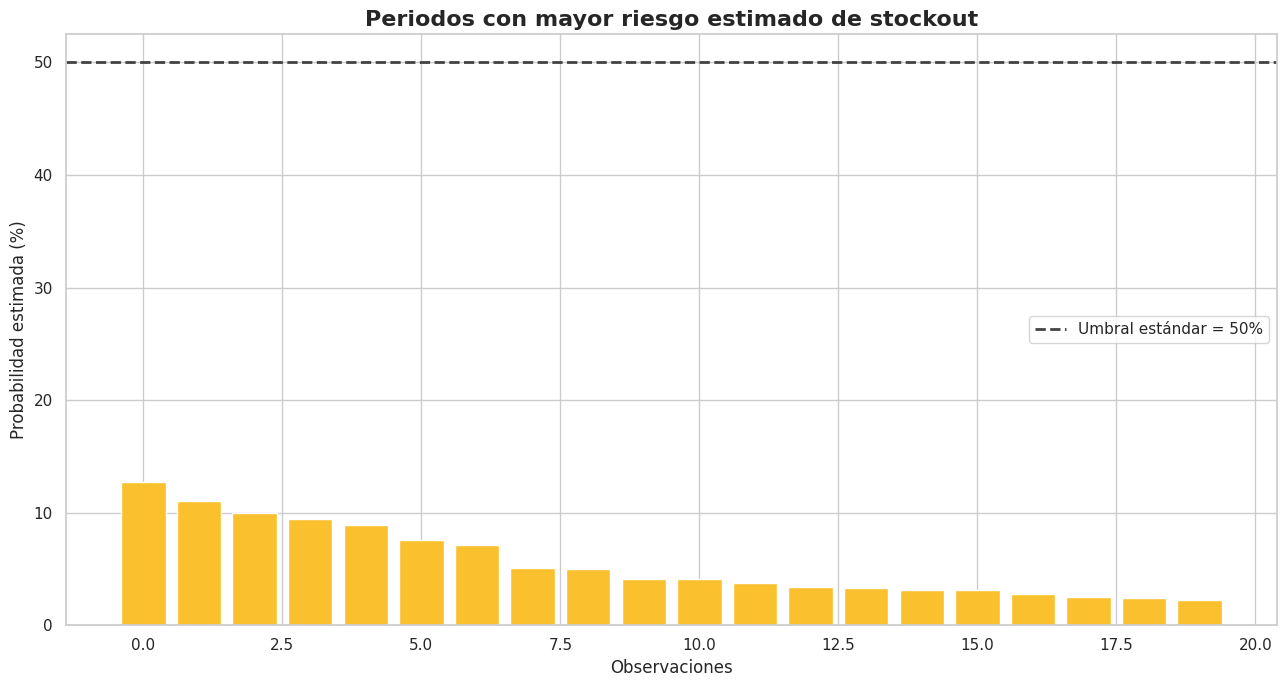


INTERPRETACIÓN

Esta gráfica ordena las observaciones
según la probabilidad estimada de stockout.

Podemos pensar en esta información
como un SISTEMA DE ALERTAS.

Por ejemplo:

VERDE   = riesgo bajo

AMARILLO = requiere observación

NARANJA = riesgo importante

ROJO = requiere atención prioritaria


IMPORTANTE:

Los límites deberían definirse según
la tolerancia al riesgo de la empresa.

No son universales.



SEMÁFORO DE RIESGO
     Pronostico  Lead_time_dias  Riesgo_proveedor  Inventario_inicial  Probabilidad_stockout Nivel_riesgo
120         267              84                 1                 158                  12.75         BAJO
111         297              83                 2                 268                  11.07         BAJO
106         261              76                 2                 487                  10.01         BAJO
101         275              79                 1                 253                   9.43         BAJO
37          189              79     

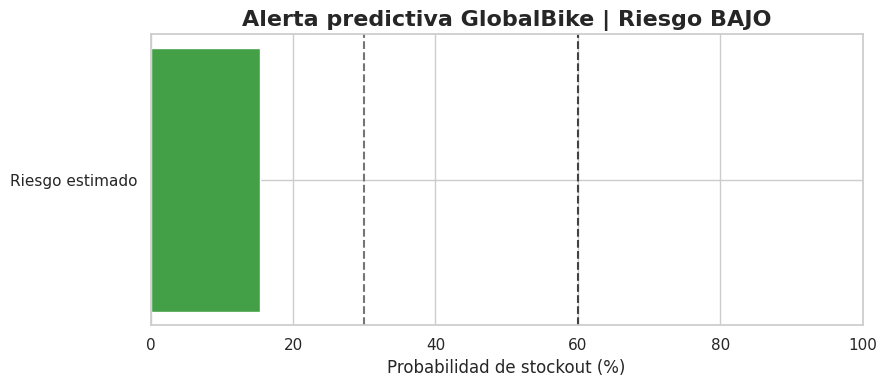



DE LA PREDICCIÓN A LA DECISIÓN

El modelo estima un riesgo de:

15.4%

Clasificación:

BAJO


PERO MACHINE LEARNING NO NOS DICE AUTOMÁTICAMENTE:

"COMPRE MÁS"

o

"CAMBIE DE PROVEEDOR".


Machine Learning nos ayuda a responder:

¿EXISTE UNA SEÑAL DE ALERTA?


La gerencia todavía debe decidir:

¿QUÉ HACER FRENTE A ESA ALERTA?


Aquí comienza la siguiente etapa del proyecto.



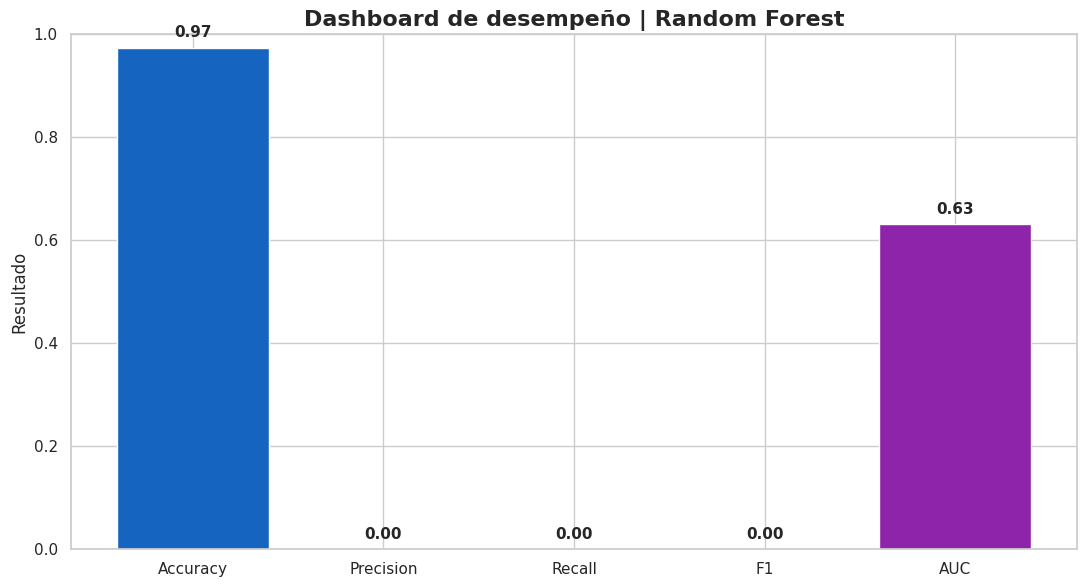



REPORTE COMPLETO DE CLASIFICACIÓN
              precision    recall  f1-score   support

Sin stockout       0.97      1.00      0.99        38
Con stockout       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39


ARCHIVOS GENERADOS:

1. GlobalBike_Machine_Learning.csv

2. GlobalBike_Importancia_Variables.csv

3. GlobalBike_Predicciones.csv



CONCLUSIÓN GERENCIAL


El modelo Random Forest permitió explorar
la posibilidad de anticipar el riesgo de stockout
del controlador E-500.

El modelo obtuvo:

Accuracy  = 97.4%

Precision = 0.0%

Recall    = 0.0%

F1-score  = 0.0%

AUC       = 0.632


Las tres variables con mayor importancia predictiva fueron:

1. Inventario_inicial

2. Error_semana_anterior

3. Lead_time_dias


Esto sugiere que estas variables contienen información
relevante para diferenciar periodos con mayor
y menor riesgo de stoc

In [1]:
# =============================================================================
# INVENTARIOS Y COMPRAS GLOBALES
# CASO INTEGRADOR: GLOBALBIKE COMPONENTS COLOMBIA S.A.S.
#
# ETAPA 8: MACHINE LEARNING
# PREDICCIÓN DEL RIESGO DE STOCKOUT DEL CONTROLADOR E-500
# =============================================================================
#
# CONTEXTO
# -----------------------------------------------------------------------------
# GlobalBike Components Colombia S.A.S. ensambla bicicletas eléctricas.
#
# Uno de sus componentes críticos es el controlador electrónico E-500,
# adquirido principalmente mediante abastecimiento internacional.
#
# En la etapa anterior (Data Analytics) encontramos que el problema de
# inventarios no depende únicamente de cuánto inventario existe.
#
# También pueden intervenir variables como:
#
# - Demanda
# - Error del pronóstico
# - Inventario disponible
# - Lead time
# - Variabilidad del proveedor
# - Compras recibidas
#
# AHORA CAMBIA NUESTRA PREGUNTA.
#
# Antes preguntábamos:
#
# ¿QUÉ ESTÁ PASANDO?
#
# Ahora preguntaremos:
#
# ¿PODEMOS ANTICIPAR EL RIESGO DE STOCKOUT?
#
# Para responder utilizaremos MACHINE LEARNING.
#
# Específicamente utilizaremos:
#
# RANDOM FOREST CLASSIFIER
#
# porque nuestro objetivo es CLASIFICAR cada periodo en:
#
# 0 = Riesgo bajo / no se espera stockout
# 1 = Riesgo alto / existe riesgo de stockout
#
# IMPORTANTE:
# -----------------------------------------------------------------------------
# Este ejercicio tiene propósito PEDAGÓGICO.
#
# Los datos son simulados.
#
# En un proyecto empresarial real deberían utilizarse datos históricos
# reales y realizar una validación más rigurosa antes de utilizar
# el modelo para tomar decisiones.
#
# =============================================================================


# =============================================================================
# 1. IMPORTAR LIBRERÍAS
# =============================================================================

# pandas:
# Manejo de bases de datos.

import pandas as pd


# numpy:
# Operaciones matemáticas y simulación.

import numpy as np


# matplotlib:
# Visualizaciones.

import matplotlib.pyplot as plt


# seaborn:
# Visualizaciones estadísticas.

import seaborn as sns


# Librerías de Machine Learning.

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


# Configuración visual.

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)

plt.rcParams["font.size"] = 11


# =============================================================================
# 2. CREAR UNA BASE DE DATOS SEMANAL
# =============================================================================
#
# ¿POR QUÉ CAMBIAMOS DE DATOS MENSUALES A SEMANALES?
#
# En el punto 7 trabajamos con 36 meses.
#
# Eso era suficiente para enseñar:
#
# - KPIs
# - gráficas
# - diagnóstico
# - correlaciones
#
# Pero 36 observaciones son muy pocas para enseñar adecuadamente
# el entrenamiento de un modelo de Machine Learning.
#
# Por eso utilizaremos:
#
# 156 semanas ≈ 3 años.
#
# IMPORTANTE:
#
# Más datos NO significa automáticamente mejor modelo.
#
# Pero necesitamos suficientes observaciones para separar:
#
# DATOS DE ENTRENAMIENTO
#
# y
#
# DATOS DE PRUEBA.


np.random.seed(42)


n_semanas = 156


fechas = pd.date_range(
    start="2024-01-01",
    periods=n_semanas,
    freq="W"
)


# =============================================================================
# 3. SIMULAR LA DEMANDA SEMANAL
# =============================================================================
#
# Supongamos que GlobalBike consume aproximadamente
# 250 controladores E-500 por semana.
#
# La demanda tendrá:
#
# - nivel base,
# - tendencia,
# - estacionalidad,
# - variabilidad aleatoria.


demanda_base = 250


# Tendencia:
# simulamos un pequeño crecimiento durante los tres años.

tendencia = np.linspace(
    0,
    50,
    n_semanas
)


# Estacionalidad:
# algunos periodos presentan mayor demanda que otros.

estacionalidad = (
    35 *
    np.sin(
        2 * np.pi *
        np.arange(n_semanas) / 52
    )
)


# Ruido:
# representa la incertidumbre natural de la demanda.

ruido = np.random.normal(
    loc=0,
    scale=30,
    size=n_semanas
)


demanda_real = (
    demanda_base
    + tendencia
    + estacionalidad
    + ruido
).round()


demanda_real = np.maximum(
    demanda_real,
    120
).astype(int)


# =============================================================================
# 4. CREAR EL PRONÓSTICO
# =============================================================================
#
# Ningún forecast es perfecto.
#
# Simularemos errores alrededor de la demanda real.


error_simulado = np.random.normal(
    loc=-5,
    scale=35,
    size=n_semanas
)


pronostico = (
    demanda_real
    + error_simulado
).round()


pronostico = np.maximum(
    pronostico,
    100
).astype(int)


# =============================================================================
# 5. CALCULAR EL ERROR DEL FORECAST
# =============================================================================
#
# Fórmula:
#
# ERROR = DEMANDA REAL - PRONÓSTICO
#
#
# Si el resultado es POSITIVO:
#
# Demanda real > Pronóstico
#
# La empresa SUBESTIMÓ la demanda.
#
#
# Si el resultado es NEGATIVO:
#
# Pronóstico > Demanda real
#
# La empresa SOBREESTIMÓ la demanda.


error_pronostico = (
    demanda_real
    - pronostico
)


# =============================================================================
# 6. CALCULAR ERROR PORCENTUAL ABSOLUTO
# =============================================================================
#
#             |Demanda real - Pronóstico|
# APE = ---------------------------------------- × 100
#                      Demanda real
#
#
# Utilizamos valor absoluto porque queremos conocer
# el tamaño del error independientemente de su dirección.


ape = (
    np.abs(error_pronostico)
    /
    demanda_real
) * 100


# =============================================================================
# 7. SIMULAR LEAD TIME
# =============================================================================
#
# GlobalBike importa principalmente desde Asia.
#
# Supongamos que el lead time puede estar entre:
#
# 55 y 105 días.
#
# El promedio estará alrededor de 75 días.


lead_time = np.random.normal(
    loc=75,
    scale=13,
    size=n_semanas
)


lead_time = np.clip(
    lead_time,
    55,
    105
).round().astype(int)


# =============================================================================
# 8. CREAR RIESGO DEL PROVEEDOR
# =============================================================================
#
# Incorporaremos una variable sencilla que representa
# el nivel de riesgo observado del proveedor.
#
# Escala:
#
# 1 = riesgo bajo
# 2 = riesgo medio
# 3 = riesgo alto
#
#
# Esta variable podría construirse en una empresa real
# utilizando indicadores como:
#
# - entregas tardías,
# - calidad,
# - cumplimiento,
# - capacidad,
# - interrupciones,
# - estabilidad logística.


riesgo_proveedor = np.random.choice(
    [1, 2, 3],
    size=n_semanas,
    p=[0.50, 0.35, 0.15]
)


# =============================================================================
# 9. SIMULAR INVENTARIO INICIAL
# =============================================================================
#
# El inventario disponible es una variable fundamental.
#
# En términos simples:
#
# MENOR INVENTARIO
#
#         +
#
# MAYOR DEMANDA
#
#         +
#
# MAYOR INCERTIDUMBRE
#
#         =
#
# MAYOR RIESGO DE STOCKOUT


inventario_inicial = np.random.normal(
    loc=320,
    scale=95,
    size=n_semanas
)


inventario_inicial = np.clip(
    inventario_inicial,
    80,
    600
).round().astype(int)


# =============================================================================
# 10. SIMULAR COMPRAS RECIBIDAS
# =============================================================================
#
# No todas las semanas llegan órdenes de compra.
#
# Además, cuando el lead time aumenta o el proveedor presenta
# mayor riesgo, existe mayor posibilidad de recibir menos
# producto del esperado.
#
# Creamos primero una cantidad teórica basada en el forecast.


compras_teoricas = (
    pronostico *
    np.random.uniform(
        0.45,
        1.05,
        n_semanas
    )
)


# Penalización asociada con lead time elevado.
#
# A mayor lead time, reducimos ligeramente
# la disponibilidad de producto recibido.


penalizacion_lead_time = np.where(
    lead_time > 90,
    0.70,
    np.where(
        lead_time > 80,
        0.85,
        1.00
    )
)


# Penalización asociada con riesgo del proveedor.


penalizacion_proveedor = np.where(
    riesgo_proveedor == 3,
    0.75,
    np.where(
        riesgo_proveedor == 2,
        0.90,
        1.00
    )
)


compras_recibidas = (
    compras_teoricas
    *
    penalizacion_lead_time
    *
    penalizacion_proveedor
).round().astype(int)


# =============================================================================
# 11. CALCULAR DISPONIBILIDAD
# =============================================================================
#
# Fórmula:
#
# DISPONIBLE =
#
# INVENTARIO INICIAL + COMPRAS RECIBIDAS


disponible = (
    inventario_inicial
    +
    compras_recibidas
)


# =============================================================================
# 12. CALCULAR STOCKOUT
# =============================================================================
#
# Fórmula:
#
# STOCKOUT =
#
# MAX(
#     DEMANDA REAL - DISPONIBLE,
#     0
# )
#
#
# Ejemplo:
#
# Demanda = 300
# Disponible = 250
#
# Stockout = 50
#
#
# Pero si:
#
# Demanda = 250
# Disponible = 300
#
# Stockout = 0


stockout = np.maximum(
    demanda_real
    -
    disponible,
    0
)


# =============================================================================
# 13. CREAR LA VARIABLE OBJETIVO DEL MACHINE LEARNING
# =============================================================================
#
# Esta es una de las partes MÁS IMPORTANTES.
#
# Machine Learning necesita saber qué queremos predecir.
#
# Esa variable se denomina:
#
# TARGET
#
# VARIABLE OBJETIVO
#
# o
#
# Y
#
#
# Nuestra variable será:
#
# Riesgo_stockout
#
#
# Si ocurrió stockout:
#
# Riesgo_stockout = 1
#
#
# Si no ocurrió:
#
# Riesgo_stockout = 0


riesgo_stockout = np.where(
    stockout > 0,
    1,
    0
)


# =============================================================================
# 14. CREAR LA BASE DE DATOS
# =============================================================================


df_ml = pd.DataFrame({

    "Fecha": fechas,

    "Demanda_real": demanda_real,

    "Pronostico": pronostico,

    "Error_pronostico": error_pronostico,

    "APE": ape,

    "Lead_time_dias": lead_time,

    "Riesgo_proveedor": riesgo_proveedor,

    "Inventario_inicial": inventario_inicial,

    "Compras_recibidas": compras_recibidas,

    "Disponible": disponible,

    "Stockout": stockout,

    "Riesgo_stockout": riesgo_stockout

})


# =============================================================================
# 15. REVISAR LA BASE
# =============================================================================


print("\n")
print("=" * 75)
print("BASE DE DATOS PARA MACHINE LEARNING")
print("=" * 75)


print(
    df_ml.head(10).to_string(
        index=False
    )
)


print("\nNúmero de observaciones:")

print(
    len(df_ml)
)


# =============================================================================
# 16. ¿CUÁNTOS STOCKOUTS TENEMOS?
# =============================================================================
#
# Antes de construir un modelo debemos mirar
# nuestra variable objetivo.
#
# Esto es MUY IMPORTANTE.
#
# Si tuviéramos:
#
# 99 % SIN stockout
# 1 % CON stockout
#
# tendríamos un problema de clases desbalanceadas.
#
# Un modelo podría decir siempre "no hay stockout"
# y aparentemente tener 99 % de accuracy.
#
# Pero sería completamente inútil.


conteo_clases = (
    df_ml["Riesgo_stockout"]
    .value_counts()
    .sort_index()
)


print("\n")
print("=" * 75)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 75)


print(
    conteo_clases
)


porcentaje_stockout = (
    df_ml["Riesgo_stockout"].mean()
    * 100
)


print(
    f"\nPorcentaje de periodos con stockout: "
    f"{porcentaje_stockout:.2f}%"
)


# =============================================================================
# 17. GRÁFICA: DISTRIBUCIÓN DE STOCKOUT
# =============================================================================


plt.figure(figsize=(8, 6))


sns.countplot(

    data=df_ml,

    x="Riesgo_stockout",

    hue="Riesgo_stockout",

    palette={
        0: "#43A047",
        1: "#E53935"
    },

    legend=False

)


plt.title(
    "Distribución de periodos con y sin stockout",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "0 = Sin stockout | 1 = Con stockout"
)


plt.ylabel(
    "Número de semanas"
)


plt.tight_layout()


plt.show()


print("\nINTERPRETACIÓN")

print(
    f"""
De las {len(df_ml)} semanas analizadas,
aproximadamente {porcentaje_stockout:.1f}% presentan stockout.

Antes de entrenar cualquier modelo debemos observar
si las dos categorías están razonablemente representadas.

Esto es importante porque un modelo puede parecer
muy preciso simplemente por predecir siempre
la categoría mayoritaria.
"""
)


# =============================================================================
# 18. DEFINIR VARIABLES PREDICTORAS
# =============================================================================
#
# En Machine Learning normalmente utilizamos:
#
# X = VARIABLES PREDICTORAS
#
# Y = VARIABLE QUE QUEREMOS PREDECIR
#
#
# Para nuestro ejemplo utilizaremos:
#
# Pronóstico
# Error del pronóstico
# APE
# Lead time
# Riesgo del proveedor
# Inventario inicial
#
#
# ATENCIÓN:
#
# NO utilizaremos:
#
# Stockout
# Disponible
# Compras recibidas
#
# si estas variables solamente se conocen después
# de ocurrido el evento que queremos predecir.
#
# Esto evita lo que se denomina:
#
# DATA LEAKAGE
#
# Es decir:
#
# darle al modelo información del futuro
# que en una situación real no estaría disponible.
#
# Este es un concepto MUY IMPORTANTE.


variables_predictoras = [

    "Pronostico",

    "Error_pronostico",

    "APE",

    "Lead_time_dias",

    "Riesgo_proveedor",

    "Inventario_inicial"

]


X = df_ml[
    variables_predictoras
]


y = df_ml[
    "Riesgo_stockout"
]


# =============================================================================
# 19. ACLARACIÓN PEDAGÓGICA SOBRE EL ERROR DEL PRONÓSTICO
# =============================================================================
#
# IMPORTANTE:
#
# En un sistema REAL para anticipar stockout,
# el "Error_pronostico" del mismo periodo todavía no sería conocido,
# porque necesitamos conocer la demanda real para calcularlo.
#
# Aquí lo utilizamos para enseñar la lógica del modelo.
#
# En una implementación real sería mejor utilizar:
#
# - error del forecast de la semana anterior,
# - MAPE histórico,
# - desviación del forecast,
# - volatilidad histórica de demanda.
#
# Más adelante crearemos también una variable histórica
# para mostrar esta lógica.


# =============================================================================
# 20. CREAR ERROR HISTÓRICO
# =============================================================================
#
# shift(1) desplaza la información un periodo.
#
# Así:
#
# Error_historico_semana_anterior
#
# contiene el error observado en la semana anterior.
#
# Esta información SÍ podría estar disponible
# cuando hacemos una nueva predicción.


df_ml[
    "Error_semana_anterior"
] = (
    df_ml["Error_pronostico"]
    .shift(1)
)


# Hacemos lo mismo con APE.


df_ml[
    "APE_semana_anterior"
] = (
    df_ml["APE"]
    .shift(1)
)


# La primera fila queda vacía porque no existe
# una semana anterior.
#
# La eliminamos.


df_ml = (
    df_ml
    .dropna()
    .reset_index(drop=True)
)


# =============================================================================
# 21. DEFINIR LAS VARIABLES DEFINITIVAS
# =============================================================================
#
# Ahora utilizaremos variables más razonables
# desde una perspectiva predictiva.


variables_predictoras = [

    "Pronostico",

    "Error_semana_anterior",

    "APE_semana_anterior",

    "Lead_time_dias",

    "Riesgo_proveedor",

    "Inventario_inicial"

]


X = df_ml[
    variables_predictoras
]


y = df_ml[
    "Riesgo_stockout"
]


# =============================================================================
# 22. DIVIDIR DATOS EN ENTRENAMIENTO Y PRUEBA
# =============================================================================
#
# Este concepto es fundamental.
#
# NO debemos entrenar y evaluar el modelo
# utilizando exactamente los mismos datos.
#
# Sería parecido a:
#
# entregar a un estudiante las respuestas del examen,
# permitirle memorizarlas
# y después evaluarlo con exactamente las mismas preguntas.
#
#
# Dividiremos:
#
# 75 % = ENTRENAMIENTO
#
# 25 % = PRUEBA
#
#
# ENTRENAMIENTO:
# el modelo aprende.
#
# PRUEBA:
# evaluamos si puede trabajar con información
# que no utilizó para aprender.


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.25,

    random_state=42,

    stratify=y

)


print("\n")
print("=" * 75)
print("DIVISIÓN DE LOS DATOS")
print("=" * 75)


print(
    f"Datos de entrenamiento: "
    f"{len(X_train)}"
)


print(
    f"Datos de prueba: "
    f"{len(X_test)}"
)


# =============================================================================
# 23. ¿QUÉ ES RANDOM FOREST?
# =============================================================================
#
# Antes de programarlo, entendamos la lógica.
#
# RANDOM FOREST significa:
#
# BOSQUE ALEATORIO.
#
# En lugar de utilizar un único árbol de decisión,
# construye MUCHOS árboles.
#
#
# Podemos imaginarlo así:
#
#                DATOS
#
#                  ↓
#
#        ┌─────────┼─────────┐
#
#        ↓         ↓         ↓
#
#     Árbol 1   Árbol 2   Árbol 3 ...
#
#        ↓         ↓         ↓
#
#      Riesgo    No       Riesgo
#
#                  ↓
#
#             VOTACIÓN FINAL
#
#
# Cada árbol analiza combinaciones diferentes
# de observaciones y variables.
#
# Después el bosque toma una decisión conjunta.
#
# Esto suele hacerlo más robusto que depender
# de un único árbol.


# =============================================================================
# 24. CREAR EL MODELO
# =============================================================================
#
# n_estimators = 300
#
# Significa que utilizaremos 300 árboles.
#
#
# max_depth = 5
#
# Limita la profundidad de cada árbol.
#
# Esto ayuda a evitar que el modelo memorice
# excesivamente los datos.
#
#
# class_weight = "balanced"
#
# Le indica al modelo que tenga en cuenta
# posibles diferencias entre las clases.
#
#
# random_state = 42
#
# Hace que podamos reproducir los resultados.


modelo = RandomForestClassifier(

    n_estimators=300,

    max_depth=5,

    min_samples_leaf=3,

    class_weight="balanced",

    random_state=42

)


# =============================================================================
# 25. ENTRENAR EL MODELO
# =============================================================================
#
# fit() significa:
#
# "APRENDE A PARTIR DE ESTOS DATOS"


modelo.fit(
    X_train,
    y_train
)


# =============================================================================
# 26. HACER PREDICCIONES
# =============================================================================
#
# predict() genera la clasificación:
#
# 0 = bajo riesgo
#
# 1 = alto riesgo


y_pred = modelo.predict(
    X_test
)


# predict_proba() genera PROBABILIDADES.
#
# Por ejemplo:
#
# 0.82
#
# significaría:
#
# el modelo estima una probabilidad de 82 %
# de pertenecer a la categoría "riesgo de stockout".
#
# IMPORTANTE:
#
# Esta probabilidad es una estimación del modelo,
# no una certeza.


y_prob = modelo.predict_proba(
    X_test
)[:, 1]


# =============================================================================
# 27. CALCULAR ACCURACY
# =============================================================================
#
# ACCURACY =
#
#                Predicciones correctas
# ------------------------------------------------
#                 Total de predicciones
#
#
# Ejemplo:
#
# 80 predicciones correctas
# de 100
#
# Accuracy = 80 %
#
#
# PERO:
#
# Accuracy NO debe utilizarse sola.
#
# Especialmente cuando las categorías
# están desbalanceadas.


accuracy = accuracy_score(
    y_test,
    y_pred
)


# =============================================================================
# 28. PRECISION
# =============================================================================
#
# PRECISION responde:
#
# De todos los periodos que el modelo dijo
# que tenían riesgo...
#
# ¿cuántos realmente tenían riesgo?
#
#
# Fórmula:
#
#                    Verdaderos Positivos
# Precision = --------------------------------
#             Verdaderos Positivos + Falsos Positivos


precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)


# =============================================================================
# 29. RECALL
# =============================================================================
#
# RECALL responde:
#
# De todos los stockouts que realmente ocurrieron...
#
# ¿cuántos logró detectar el modelo?
#
#
# Fórmula:
#
#                 Verdaderos Positivos
# Recall = --------------------------------
#          Verdaderos Positivos + Falsos Negativos
#
#
# PARA GLOBALBIKE:
#
# Recall puede ser especialmente importante.
#
# ¿Por qué?
#
# Porque un FALSO NEGATIVO significa:
#
# el modelo dijo:
#
# "NO HAY RIESGO"
#
# pero realmente:
#
# SÍ OCURRIÓ STOCKOUT.
#
#
# Esto puede ser costoso para la operación.


recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)


# =============================================================================
# 30. F1-SCORE
# =============================================================================
#
# F1 combina:
#
# PRECISION
#
# y
#
# RECALL
#
#
# Fórmula:
#
#                 Precision × Recall
# F1 = 2 × --------------------------------
#                 Precision + Recall
#
#
# Es útil cuando queremos equilibrio
# entre ambas métricas.


f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# =============================================================================
# 31. AUC
# =============================================================================
#
# AUC mide la capacidad del modelo
# para diferenciar entre:
#
# STOCKOUT
#
# y
#
# NO STOCKOUT.
#
#
# De forma orientativa:
#
# 0.50 = discriminación equivalente al azar
#
# 1.00 = separación perfecta
#
#
# IMPORTANTE:
#
# No debemos utilizar estos rangos
# como reglas universales.
#
# Siempre debemos interpretar el resultado
# según el problema empresarial.


auc = roc_auc_score(
    y_test,
    y_prob
)


# =============================================================================
# 32. MOSTRAR RESULTADOS
# =============================================================================


print("\n")
print("=" * 75)
print("RESULTADOS DEL MODELO RANDOM FOREST")
print("=" * 75)


print(
    f"\nAccuracy:  {accuracy:.2%}"
)


print(
    f"Precision: {precision:.2%}"
)


print(
    f"Recall:    {recall:.2%}"
)


print(
    f"F1-score:  {f1:.2%}"
)


print(
    f"AUC:       {auc:.3f}"
)


# =============================================================================
# 33. INTERPRETACIÓN AUTOMÁTICA
# =============================================================================


print("\nINTERPRETACIÓN DE LAS MÉTRICAS")


print(
    f"""
ACCURACY = {accuracy:.1%}

Representa el porcentaje total de predicciones correctas.


PRECISION = {precision:.1%}

De las semanas que el modelo clasificó como
"alto riesgo de stockout",
aproximadamente este porcentaje realmente presentó stockout.


RECALL = {recall:.1%}

De todos los stockouts que realmente ocurrieron,
el modelo logró identificar aproximadamente este porcentaje.


F1-SCORE = {f1:.1%}

Resume el equilibrio entre Precision y Recall.


AUC = {auc:.3f}

Resume la capacidad del modelo para diferenciar
periodos con y sin riesgo.


PREGUNTA GERENCIAL:

Para GlobalBike, ¿qué sería más costoso?

A) Generar una alerta que finalmente no termina en stockout.

B) No generar una alerta y que posteriormente ocurra el stockout.

Esta pregunta es importante porque las métricas
del modelo deben interpretarse desde el impacto empresarial.
"""
)


# =============================================================================
# 34. MATRIZ DE CONFUSIÓN
# =============================================================================
#
# La matriz de confusión nos permite entender
# QUÉ TIPO DE ERRORES comete el modelo.
#
#
#                        PREDICCIÓN
#
#                     NO         SÍ
#
# REAL   NO            TN         FP
#
#        SÍ            FN         TP
#
#
# TN = Verdadero Negativo
#
# FP = Falso Positivo
#
# FN = Falso Negativo
#
# TP = Verdadero Positivo
#
#
# PARA GLOBALBIKE:
#
# FALSO NEGATIVO = especialmente importante.
#
# El modelo dijo:
#
# "No hay riesgo"
#
# pero realmente ocurrió stockout.


matriz = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(8, 6))


sns.heatmap(

    matriz,

    annot=True,

    fmt="d",

    cmap="Blues",

    cbar=False,

    xticklabels=[
        "Sin stockout",
        "Con stockout"
    ],

    yticklabels=[
        "Sin stockout",
        "Con stockout"
    ]

)


plt.title(
    "Matriz de Confusión | Random Forest",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Predicción del modelo"
)


plt.ylabel(
    "Situación real"
)


plt.tight_layout()


plt.show()


# Extraemos los cuatro valores.


tn, fp, fn, tp = matriz.ravel()


print("\nINTERPRETACIÓN DE LA MATRIZ")


print(
    f"""
VERDADEROS NEGATIVOS = {tn}

El modelo dijo "sin riesgo"
y efectivamente no ocurrió stockout.


FALSOS POSITIVOS = {fp}

El modelo generó una alerta,
pero finalmente no ocurrió stockout.


FALSOS NEGATIVOS = {fn}

El modelo NO generó alerta,
pero sí ocurrió stockout.

Para GlobalBike este error puede ser especialmente crítico.


VERDADEROS POSITIVOS = {tp}

El modelo generó alerta
y efectivamente ocurrió stockout.
"""
)


# =============================================================================
# 35. CURVA ROC
# =============================================================================
#
# La curva ROC permite observar el comportamiento
# del modelo para diferentes umbrales de clasificación.
#
# Recordemos:
#
# Por defecto:
#
# Probabilidad >= 0.50
#
# suele clasificarse como:
#
# RIESGO = 1
#
#
# Pero una empresa podría decidir utilizar:
#
# 0.40
#
# 0.30
#
# u otro umbral.
#
# Esto depende del costo de los errores.


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


plt.figure(figsize=(9, 7))


plt.plot(

    fpr,

    tpr,

    color="#1565C0",

    linewidth=3,

    label=f"Random Forest | AUC = {auc:.3f}"

)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    color="#757575",

    label="Clasificación aleatoria"

)


plt.fill_between(

    fpr,

    tpr,

    alpha=0.15,

    color="#42A5F5"

)


plt.title(
    "Curva ROC | Predicción del riesgo de stockout",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Tasa de falsos positivos"
)


plt.ylabel(
    "Tasa de verdaderos positivos"
)


plt.legend()


plt.tight_layout()


plt.show()


print("\nINTERPRETACIÓN CURVA ROC")


print(
    f"""
El AUC obtenido es {auc:.3f}.

La curva ROC permite analizar la capacidad
del modelo para separar semanas con riesgo
y semanas sin riesgo.

Cuanto mayor sea la separación respecto
a la diagonal, mayor es la capacidad discriminatoria
del modelo dentro de esta muestra.

Sin embargo, el objetivo empresarial
no es conseguir una gráfica bonita.

El objetivo es utilizar la predicción
para tomar una decisión antes del stockout.
"""
)


# =============================================================================
# 36. IMPORTANCIA DE VARIABLES
# =============================================================================
#
# Random Forest permite estimar qué variables
# contribuyeron más a las decisiones del modelo.
#
# IMPORTANTE:
#
# "IMPORTANCIA"
#
# NO SIGNIFICA
#
# "CAUSALIDAD".
#
#
# Si lead time aparece como importante,
# podemos decir:
#
# "El lead time aportó información relevante
# para las predicciones del modelo."
#
#
# NO debemos afirmar automáticamente:
#
# "El lead time causa los stockouts."


importancias = pd.DataFrame({

    "Variable":
        variables_predictoras,

    "Importancia":
        modelo.feature_importances_

})


importancias = (
    importancias
    .sort_values(
        "Importancia",
        ascending=False
    )
)


print("\n")
print("=" * 75)
print("IMPORTANCIA DE VARIABLES")
print("=" * 75)


print(
    importancias.to_string(
        index=False
    )
)


# =============================================================================
# 37. GRÁFICA IMPORTANCIA DE VARIABLES
# =============================================================================


plt.figure(figsize=(10, 7))


colores_importancia = [

    "#1565C0",
    "#00897B",
    "#43A047",
    "#F9A825",
    "#EF6C00",
    "#8E24AA"

]


sns.barplot(

    data=importancias,

    x="Importancia",

    y="Variable",

    hue="Variable",

    palette=colores_importancia,

    legend=False

)


plt.title(
    "¿Qué variables aportan más a la predicción?",
    fontsize=16,
    fontweight="bold"
)


plt.xlabel(
    "Importancia relativa"
)


plt.ylabel(
    ""
)


plt.tight_layout()


plt.show()


variable_mas_importante = (
    importancias.iloc[0]["Variable"]
)


importancia_principal = (
    importancias.iloc[0]["Importancia"]
)


print("\nINTERPRETACIÓN")


print(
    f"""
La variable con mayor importancia predictiva
en este ejercicio fue:

{variable_mas_importante}

con una importancia aproximada de:

{importancia_principal:.1%}

Esto NO significa necesariamente
que esta variable cause el stockout.

Significa que fue especialmente útil
para que Random Forest diferenciara
entre situaciones con y sin riesgo.

Esta información puede orientar
la investigación gerencial posterior.
"""
)


# =============================================================================
# 38. COMPARAR REAL VS PREDICCIÓN
# =============================================================================
#
# Ahora construiremos una tabla
# para observar algunas predicciones individuales.


resultados = X_test.copy()


resultados[
    "Situacion_real"
] = y_test.values


resultados[
    "Prediccion_modelo"
] = y_pred


resultados[
    "Probabilidad_stockout"
] = y_prob


resultados[
    "Probabilidad_stockout"
] = (
    resultados[
        "Probabilidad_stockout"
    ] * 100
)


resultados = (
    resultados
    .sort_values(
        "Probabilidad_stockout",
        ascending=False
    )
)


print("\n")
print("=" * 75)
print("EJEMPLOS DE PREDICCIONES")
print("=" * 75)


print(
    resultados.head(15).round(2).to_string()
)


# =============================================================================
# 39. GRÁFICA DE PROBABILIDAD DE RIESGO
# =============================================================================
#
# Mostraremos las 20 observaciones
# con mayor riesgo estimado.


top_riesgo = (
    resultados
    .head(20)
    .copy()
)


top_riesgo = (
    top_riesgo
    .reset_index()
)


colores_riesgo = [

    "#C62828"
    if x >= 70

    else "#EF6C00"
    if x >= 50

    else "#FBC02D"

    for x in top_riesgo[
        "Probabilidad_stockout"
    ]

]


plt.figure(figsize=(13, 7))


plt.bar(

    range(len(top_riesgo)),

    top_riesgo[
        "Probabilidad_stockout"
    ],

    color=colores_riesgo

)


plt.axhline(

    50,

    color="#424242",

    linestyle="--",

    linewidth=2,

    label="Umbral estándar = 50%"

)


plt.title(
    "Periodos con mayor riesgo estimado de stockout",
    fontsize=16,
    fontweight="bold"
)


plt.ylabel(
    "Probabilidad estimada (%)"
)


plt.xlabel(
    "Observaciones"
)


plt.legend()


plt.tight_layout()


plt.show()


print("\nINTERPRETACIÓN")


print(
    """
Esta gráfica ordena las observaciones
según la probabilidad estimada de stockout.

Podemos pensar en esta información
como un SISTEMA DE ALERTAS.

Por ejemplo:

VERDE   = riesgo bajo

AMARILLO = requiere observación

NARANJA = riesgo importante

ROJO = requiere atención prioritaria


IMPORTANTE:

Los límites deberían definirse según
la tolerancia al riesgo de la empresa.

No son universales.
"""
)


# =============================================================================
# 40. CREAR UN SEMÁFORO DE RIESGO
# =============================================================================
#
# Vamos a transformar la probabilidad
# en una clasificación sencilla.
#
#
# MENOS DE 30 %
#
# BAJO
#
#
# ENTRE 30 % Y 60 %
#
# MEDIO
#
#
# MÁS DE 60 %
#
# ALTO
#
#
# Nuevamente:
#
# estos valores son pedagógicos.
#
# Una empresa debería calibrarlos
# según sus costos y tolerancia al riesgo.


def clasificar_riesgo(probabilidad):

    if probabilidad < 30:

        return "BAJO"

    elif probabilidad < 60:

        return "MEDIO"

    else:

        return "ALTO"


resultados[
    "Nivel_riesgo"
] = resultados[
    "Probabilidad_stockout"
].apply(
    clasificar_riesgo
)


print("\n")
print("=" * 75)
print("SEMÁFORO DE RIESGO")
print("=" * 75)


print(

    resultados[[

        "Pronostico",

        "Lead_time_dias",

        "Riesgo_proveedor",

        "Inventario_inicial",

        "Probabilidad_stockout",

        "Nivel_riesgo"

    ]]

    .head(15)

    .round(2)

    .to_string()

)


# =============================================================================
# 41. SIMULAR UNA NUEVA SEMANA
# =============================================================================
#
# Ahora viene una parte muy interesante para la clase.
#
# Imaginemos que hoy GlobalBike debe tomar
# una decisión de compra.
#
# Tenemos la siguiente información:
#
# Pronóstico = 320 unidades
#
# Error de la semana anterior = 45 unidades
#
# APE anterior = 16 %
#
# Lead time esperado = 94 días
#
# Riesgo proveedor = 3
#
# Inventario inicial = 180 unidades
#
#
# Queremos preguntarle al modelo:
#
# ¿QUÉ NIVEL DE RIESGO OBSERVA?


nueva_semana = pd.DataFrame({

    "Pronostico": [320],

    "Error_semana_anterior": [45],

    "APE_semana_anterior": [16],

    "Lead_time_dias": [94],

    "Riesgo_proveedor": [3],

    "Inventario_inicial": [180]

})


# =============================================================================
# 42. PREDECIR NUEVA SEMANA
# =============================================================================


prediccion_nueva = modelo.predict(
    nueva_semana
)[0]


probabilidad_nueva = (

    modelo.predict_proba(
        nueva_semana
    )[0][1]

    * 100

)


nivel_nuevo = clasificar_riesgo(
    probabilidad_nueva
)


print("\n")
print("=" * 75)
print("PREDICCIÓN PARA UNA NUEVA SEMANA")
print("=" * 75)


print(
    f"""

Pronóstico:
320 unidades

Lead time:
94 días

Riesgo proveedor:
3 = Alto

Inventario inicial:
180 unidades

----------------------------------------

PROBABILIDAD ESTIMADA DE STOCKOUT:

{probabilidad_nueva:.1f}%

NIVEL DE RIESGO:

{nivel_nuevo}

----------------------------------------
"""
)


# =============================================================================
# 43. VISUALIZAR LA ALERTA
# =============================================================================


if nivel_nuevo == "ALTO":

    color_alerta = "#D32F2F"

elif nivel_nuevo == "MEDIO":

    color_alerta = "#F9A825"

else:

    color_alerta = "#43A047"


plt.figure(
    figsize=(9, 4)
)


plt.barh(

    ["Riesgo estimado"],

    [probabilidad_nueva],

    color=color_alerta,

    height=0.5

)


plt.axvline(

    30,

    linestyle="--",

    color="#757575"

)


plt.axvline(

    60,

    linestyle="--",

    color="#424242"

)


plt.xlim(
    0,
    100
)


plt.xlabel(
    "Probabilidad de stockout (%)"
)


plt.title(
    f"Alerta predictiva GlobalBike | Riesgo {nivel_nuevo}",
    fontsize=16,
    fontweight="bold"
)


plt.tight_layout()


plt.show()


# =============================================================================
# 44. ¿QUÉ HACEMOS CON LA PREDICCIÓN?
# =============================================================================
#
# ESTE ES EL PUNTO MÁS IMPORTANTE.
#
# MACHINE LEARNING NO TOMA AUTOMÁTICAMENTE
# LA DECISIÓN DE COMPRAS.
#
#
# El modelo genera:
#
# INFORMACIÓN
#
#        ↓
#
# PROBABILIDAD DE RIESGO
#
#        ↓
#
# ALERTA
#
#
# Pero todavía necesitamos una decisión humana.
#
#
# Si el riesgo es alto,
# GlobalBike podría evaluar:
#
# 1. Adelantar una orden.
#
# 2. Incrementar temporalmente stock de seguridad.
#
# 3. Consultar capacidad del proveedor.
#
# 4. Utilizar un proveedor alternativo.
#
# 5. Dividir la compra entre proveedores.
#
# 6. Revisar transporte alternativo.
#
#
# Estas NO son todavía recomendaciones definitivas.
#
# Son ALTERNATIVAS que debemos evaluar.
#
#
# Esto conecta directamente con:
#
# ETAPA 9:
#
# ALTERNATIVAS DE SOLUCIÓN.
#
#
# Y después:
#
# ETAPA 10:
#
# AHP.


print("\n")
print("=" * 75)
print("DE LA PREDICCIÓN A LA DECISIÓN")
print("=" * 75)


print(
    f"""
El modelo estima un riesgo de:

{probabilidad_nueva:.1f}%

Clasificación:

{nivel_nuevo}


PERO MACHINE LEARNING NO NOS DICE AUTOMÁTICAMENTE:

"COMPRE MÁS"

o

"CAMBIE DE PROVEEDOR".


Machine Learning nos ayuda a responder:

¿EXISTE UNA SEÑAL DE ALERTA?


La gerencia todavía debe decidir:

¿QUÉ HACER FRENTE A ESA ALERTA?


Aquí comienza la siguiente etapa del proyecto.
"""
)


# =============================================================================
# 45. CONSTRUIR UN DASHBOARD RESUMEN
# =============================================================================


metricas = pd.DataFrame({

    "Indicador": [

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "AUC"

    ],

    "Resultado": [

        accuracy,

        precision,

        recall,

        f1,

        auc

    ]

})


plt.figure(
    figsize=(11, 6)
)


colores_metricas = [

    "#1565C0",

    "#00897B",

    "#43A047",

    "#F9A825",

    "#8E24AA"

]


plt.bar(

    metricas["Indicador"],

    metricas["Resultado"],

    color=colores_metricas

)


plt.ylim(
    0,
    1
)


plt.title(
    "Dashboard de desempeño | Random Forest",
    fontsize=16,
    fontweight="bold"
)


plt.ylabel(
    "Resultado"
)


# Agregar valores encima de cada barra.

for i, valor in enumerate(
    metricas["Resultado"]
):

    plt.text(

        i,

        valor + 0.02,

        f"{valor:.2f}",

        ha="center",

        fontweight="bold"

    )


plt.tight_layout()


plt.show()


# =============================================================================
# 46. REPORTE COMPLETO DE CLASIFICACIÓN
# =============================================================================
#
# sklearn también permite generar
# un reporte completo automáticamente.


print("\n")
print("=" * 75)
print("REPORTE COMPLETO DE CLASIFICACIÓN")
print("=" * 75)


print(

    classification_report(

        y_test,

        y_pred,

        target_names=[

            "Sin stockout",

            "Con stockout"

        ],

        zero_division=0

    )

)


# =============================================================================
# 47. GUARDAR RESULTADOS
# =============================================================================
#
# Guardamos la base completa para poder utilizarla
# posteriormente en el proyecto.


df_ml.to_csv(

    "GlobalBike_Machine_Learning.csv",

    index=False,

    encoding="utf-8-sig"

)


# También guardamos las importancias.


importancias.to_csv(

    "GlobalBike_Importancia_Variables.csv",

    index=False,

    encoding="utf-8-sig"

)


# Y las predicciones.


resultados.to_csv(

    "GlobalBike_Predicciones.csv",

    index=False,

    encoding="utf-8-sig"

)


print("\nARCHIVOS GENERADOS:")


print(
    """
1. GlobalBike_Machine_Learning.csv

2. GlobalBike_Importancia_Variables.csv

3. GlobalBike_Predicciones.csv
"""
)


# =============================================================================
# 48. CONCLUSIÓN AUTOMÁTICA DEL ANÁLISIS
# =============================================================================


top_3 = (
    importancias
    .head(3)["Variable"]
    .tolist()
)


print("\n")
print("=" * 75)
print("CONCLUSIÓN GERENCIAL")
print("=" * 75)


print(
    f"""

El modelo Random Forest permitió explorar
la posibilidad de anticipar el riesgo de stockout
del controlador E-500.

El modelo obtuvo:

Accuracy  = {accuracy:.1%}

Precision = {precision:.1%}

Recall    = {recall:.1%}

F1-score  = {f1:.1%}

AUC       = {auc:.3f}


Las tres variables con mayor importancia predictiva fueron:

1. {top_3[0]}

2. {top_3[1]}

3. {top_3[2]}


Esto sugiere que estas variables contienen información
relevante para diferenciar periodos con mayor
y menor riesgo de stockout.

Sin embargo:

IMPORTANCIA PREDICTIVA NO SIGNIFICA CAUSALIDAD.


El modelo debe entenderse como una herramienta
de apoyo a la decisión y no como un reemplazo
del criterio del responsable de Supply Chain.


La pregunta que sigue ya no es:

¿PODEMOS ANTICIPAR EL RIESGO?


Ahora debemos preguntar:

¿QUÉ PODEMOS HACER CUANDO DETECTAMOS
UN RIESGO ELEVADO?


Esto nos conduce al:

PUNTO 9

ALTERNATIVAS DE SOLUCIÓN.
"""
)


# =============================================================================
# FIN DE LA ETAPA 8
# =============================================================================
#
#
#                     DATOS HISTÓRICOS
#
#                            ↓
#
#                    VARIABLES DE ENTRADA
#
#                            ↓
#
#                     RANDOM FOREST
#
#                            ↓
#
#                 PROBABILIDAD DE STOCKOUT
#
#                            ↓
#
#                      ALERTA DE RIESGO
#
#                            ↓
#
#               ¿QUÉ DEBERÍAMOS HACER?
#
#                            ↓
#
#               ALTERNATIVAS DE SOLUCIÓN
#
#                            ↓
#
#                          AHP
#
#
# =============================================================================